## IMPORTING LIBRARIES

In [1]:
import sklearn
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# DATA LOADING

In [2]:
df = pd.read_csv("C:\\Users\\Rishi\\Downloads\\Nifty Bank Historical Data.csv")

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace = True)

C:\Users\RISHI\AppData\Local\Temp\ipykernel_15844\298743900.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


# DATA CLEANING

In [7]:
df.drop("Change %",axis="columns",inplace=True)
df.drop("Vol.",axis="columns",inplace=True)
df.drop("Date",axis="columns",inplace=True)

In [8]:
df.shape

(2474, 4)

In [5]:
def conv_str(column):
    df[column]=df[column].replace(',','',regex=True)
    df[column]=df[column].astype(float)
    
def conv_str1(column):
    df[column]=df[column].replace('-','',regex=True)
    df[column]=df[column].astype(float)
    

In [6]:

conv_str('Price')
conv_str('Open')
conv_str('High')
conv_str('Low')
#conv_str1('Date')

df.head(10)

,Date,Price,Open,High,Low
0,30-08-2024,51351.00,51437.45,51466.55,51256.00
1,29-08-2024,51152.75,51103.75,51368.95,50984.40
2,28-08-2024,51143.85,51208.95,51260.75,51033.70
3,27-08-2024,51278.75,51214.05,51404.70,50938.10
4,26-08-2024,51148.10,51100.65,51317.85,51061.55
5,23-08-2024,50933.45,51040.05,51117.85,50856.70
6,22-08-2024,50985.70,50894.80,51080.00,50794.45
7,21-08-2024,50685.55,50666.65,50772.45,50333.35
8,20-08-2024,50803.15,50417.25,51025.60,50398.60
9,19-08-2024,50368.35,50683.55,50728.25,50283.55


In [8]:
scale_columns = list(df.columns.values)

In [12]:
df['Price'] = df['Price'].astype('int64')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2474 entries, 0 to 2473
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   2474 non-null   int64
 1   Open    2474 non-null   int64
 2   High    2474 non-null   int64
 3   Low     2474 non-null   int64
dtypes: int64(4)
memory usage: 77.4 KB


In [14]:
X=df.drop("Open",axis="columns")
Y=df["Open"]

In [15]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=5)

In [17]:
X_train

,Price,High,Low
1816,22720,22743,22449
814,34606,34694,33559
1686,25291,25385,25166
823,32904,33259,32771
703,39115,39775,38426
...,...,...,...
1032,22628,22674,22040
2121,15162,15211,14890
1424,26857,27037,26791
1725,24831,24948,24737


In [17]:
X_test.shape

(495, 2)

In [18]:
Y_test.shape

(495,)

In [19]:
Y_train.shape

(1979,)

# PERFORMANCE OF ML AND DL ALGOS BEFORE APPLYING SMOTEENN

# LogisticRegression

In [20]:
df.head(10)

,Open,High,Low
Date,,,
2024-08-30,51437,51466,51256
2024-08-29,51103,51368,50984
2024-08-28,51208,51260,51033
2024-08-27,51214,51404,50938
2024-08-26,51100,51317,51061
2024-08-23,51040,51117,50856
2024-08-22,50894,51080,50794
2024-08-21,50666,50772,50333
2024-08-20,50417,51025,50398


# RANDOM FOREST CLASSIFIER

In [18]:
RFC=RandomForestClassifier()
RFC.fit(X_train,Y_train)

RandomForestClassifier()

In [19]:
RFC_y_pred=RFC.predict(X_test)
print("Accuracy of RFC classifier on test data:{:.2f}".format(RFC.score(X_test,Y_test)))

Accuracy of RFC classifier on test data:0.00


In [35]:
print(classification_report(Y_test,RFC_y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.85       999
           1       0.67      0.50      0.57       408

    accuracy                           0.78      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.77      0.78      0.77      1407



In [36]:
RFC1_cm=confusion_matrix(Y_test,RFC_y_pred)
print(RFC1_cm)

[[897 102]
 [203 205]]


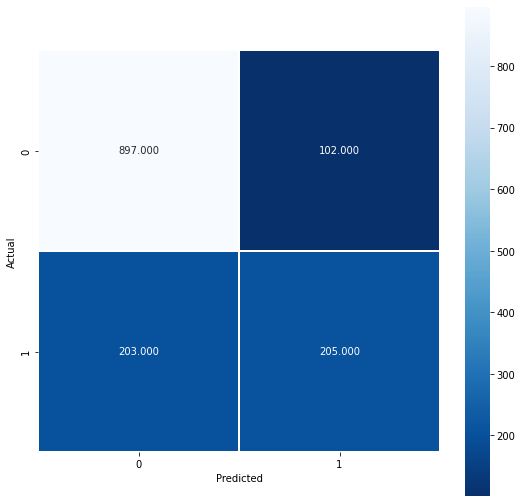

In [37]:
plt.figure(figsize=(9,9))
sns.heatmap(RFC1_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [38]:
print(roc_auc_score(Y_test,RFC_y_pred))

0.7001744391450273


# XGBOOST

In [20]:
XGB=XGBClassifier()
XGB.fit(X_train,Y_train)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [   0    1    2 ... 1912 1913 1914], got [13715 13818 13844 ... 52874 52980 53357]

In [40]:
XGB_y_pred=XGB.predict(X_test)
print("Accuracy of XGB classifier on test data:{:.2f}".format(XGB.score(X_test,Y_test)))

Accuracy of XGB classifier on test data:0.78


In [41]:
print(classification_report(Y_test,XGB_y_pred))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       999
           1       0.65      0.52      0.58       408

    accuracy                           0.78      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.77      0.78      0.77      1407



In [42]:
XGB1_cm=confusion_matrix(Y_test,XGB_y_pred)
print(XGB1_cm)

[[882 117]
 [194 214]]


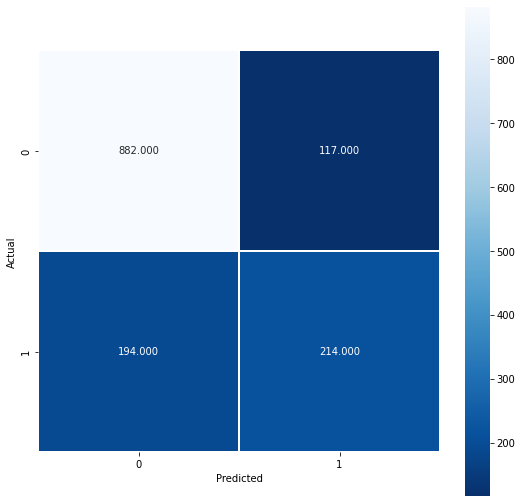

In [43]:
plt.figure(figsize=(9,9))
sns.heatmap(XGB1_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [44]:
print(roc_auc_score(Y_test,XGB_y_pred))

0.7036963434022258


# Naive Bayes

In [21]:
GNB=GaussianNB()
GNB.fit(X_train,Y_train)

GaussianNB()

In [22]:
GNB_y_pred=GNB.predict(X_test)
print("Accuracy of GNB classifier on test data:{:.2f}".format(GNB.score(X_test,Y_test)))

Accuracy of GNB classifier on test data:0.00


In [47]:
print(classification_report(Y_test,GNB_y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.80       999
           1       0.55      0.80      0.65       408

    accuracy                           0.75      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.75      0.76      1407



In [48]:
GNB1_cm=confusion_matrix(Y_test,GNB_y_pred)
print(GNB1_cm)

[[728 271]
 [ 82 326]]


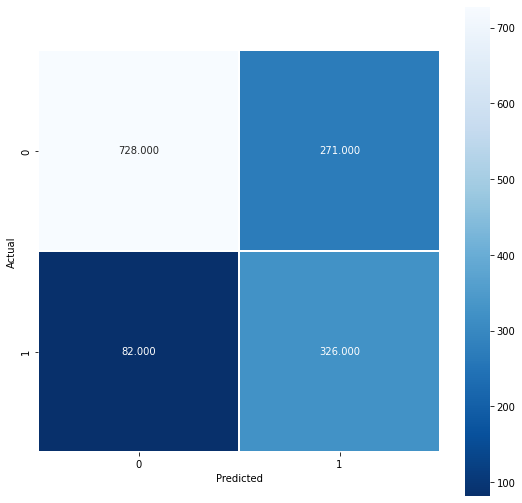

In [49]:
plt.figure(figsize=(9,9))
sns.heatmap(GNB1_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [50]:
print(roc_auc_score(Y_test,GNB_y_pred))

0.763874168285933


# DEEP LEARNING MODEL

In [23]:
model = keras.Sequential([
    keras.layers.Dense(26, input_shape=(3,), activation="relu"),
    keras.layers.Dense(15, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid"),
    
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
             
             
             
             


In [24]:
model.fit(X_train,Y_train,epochs=100)

Epoch 1/100
62/62 [==============================] - 1s 900us/step - loss: -1324440960.0000 - accuracy: 0.0000e+00
Epoch 2/100
62/62 [==============================] - 0s 850us/step - loss: -3526934272.0000 - accuracy: 0.0000e+00
Epoch 3/100
62/62 [==============================] - 0s 867us/step - loss: -8060735488.0000 - accuracy: 0.0000e+00
Epoch 4/100
62/62 [==============================] - 0s 1ms/step - loss: -16285977600.0000 - accuracy: 0.0000e+00
Epoch 5/100
62/62 [==============================] - 0s 867us/step - loss: -29653438464.0000 - accuracy: 0.0000e+00
Epoch 6/100
62/62 [==============================] - 0s 883us/step - loss: -49606754304.0000 - accuracy: 0.0000e+00
Epoch 7/100
62/62 [==============================] - 0s 867us/step - loss: -77668098048.0000 - accuracy: 0.0000e+00
Epoch 8/100
62/62 [==============================] - 0s 883us/step - loss: -114974343168.0000 - accuracy: 0.0000e+00
Epoch 9/100
62/62 [==============================] - 0s 899us/step - loss: -

Epoch 70/100
62/62 [==============================] - 0s 883us/step - loss: -45743893118976.0000 - accuracy: 0.0000e+00
Epoch 71/100
62/62 [==============================] - 0s 834us/step - loss: -47380074332160.0000 - accuracy: 0.0000e+00
Epoch 72/100
62/62 [==============================] - 0s 867us/step - loss: -49050346848256.0000 - accuracy: 0.0000e+00
Epoch 73/100
62/62 [==============================] - 0s 867us/step - loss: -50754794553344.0000 - accuracy: 0.0000e+00
Epoch 74/100
62/62 [==============================] - 0s 817us/step - loss: -52490473046016.0000 - accuracy: 0.0000e+00
Epoch 75/100
62/62 [==============================] - 0s 817us/step - loss: -54260100235264.0000 - accuracy: 0.0000e+00
Epoch 76/100
62/62 [==============================] - 0s 850us/step - loss: -56064905052160.0000 - accuracy: 0.0000e+00
Epoch 77/100
62/62 [==============================] - 0s 899us/step - loss: -57900156321792.0000 - accuracy: 0.0000e+00
Epoch 78/100
62/62 [====================

In [25]:
model.evaluate(X_test,Y_test)

16/16 [==============================] - 0s 865us/step - loss: -107835773943808.0000 - accuracy: 0.0000e+00


[-107835773943808.0, 0.0]

In [26]:
model_y_pred=model.predict(X_test)
y_pred = np.argmax(model_y_pred,axis=-1)
y_pred

16/16 [==============================] - 0s 731us/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(Y_test, model_y_pred_classes)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(Y_test, model_y_pred_classes)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(Y_test, model_y_pred_classes)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(Y_test, model_y_pred_classes)
print('F1 score: %f' % f1)

NameError: name 'model_y_pred_classes' is not defined

In [77]:
model1_cm=confusion_matrix(Y_test,model_y_pred_classes)
print(model1_cm)

[[861 138]
 [181 227]]


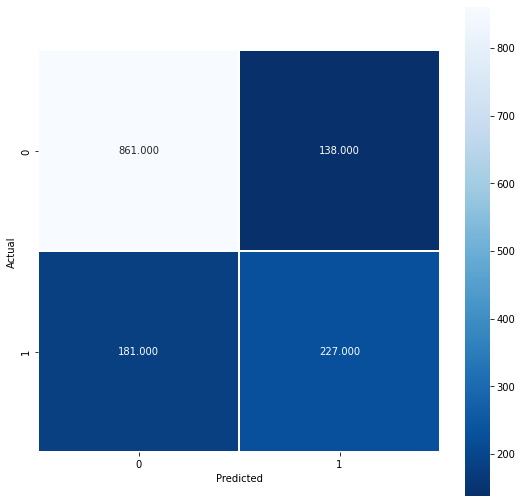

In [78]:
plt.figure(figsize=(9,9))
sns.heatmap(model1_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [62]:
print(roc_auc_score(Y_test,model_y_pred))

0.6609428055506488


In [80]:
All_Models=["LogisticRegression","RandomForestClassifier","XGBClassifier","GaussianNB","Deep Learning Model"]
Accuracies=[79,78,78,75,77]
c = ['red', 'yellow', 'pink', 'blue', 'green']

Text(0.5, 1.0, 'PERFORMANCE OF ALL MODELS BEFORE APPLYING SMOTEENN')

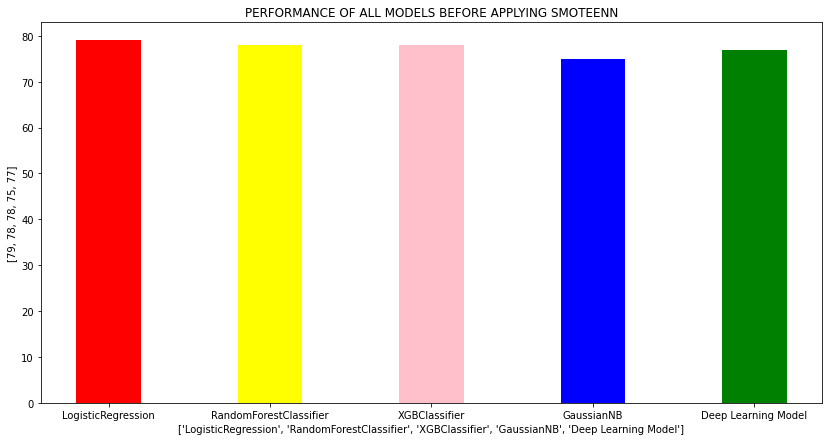

In [81]:
fig = plt.figure(figsize = (14, 7))
plt.bar(All_Models, Accuracies, color = c,width = 0.4)
plt.xlabel(All_Models)
plt.ylabel(Accuracies)
plt.title('PERFORMANCE OF ALL MODELS BEFORE APPLYING SMOTEENN')

# APPLYING SMOTEENN FUNCTION TO THE DATASET

In [54]:
sm = SMOTEENN()
X_resampled, Y_resampled = sm.fit_resample(X,Y)
Xr_train,Xr_test,Yr_train,Yr_test=train_test_split(X_resampled, Y_resampled,test_size=0.2)

# DEEP LEARNING AND MACHINE LEARNING ALGOS AFTER APPLYING SMOTEENN FUNCTION TO THE DATASET

# RANDOM FOREST

In [55]:
RFC=RandomForestClassifier()
RFC.fit(Xr_train,Yr_train)

RandomForestClassifier()

In [56]:
RFC_yr_pred=RFC.predict(Xr_test)
print("Accuracy of RFC classifier on test data:{:.2f}".format(RFC.score(Xr_test,Yr_test)))

Accuracy of RFC classifier on test data:0.95


In [57]:
print(classification_report(Yr_test,RFC_yr_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       558
           1       0.94      0.97      0.96       691

    accuracy                           0.95      1249
   macro avg       0.95      0.95      0.95      1249
weighted avg       0.95      0.95      0.95      1249



In [58]:
RFC2_cm=confusion_matrix(Yr_test,RFC_yr_pred)
print(RFC2_cm)

[[519  39]
 [ 22 669]]


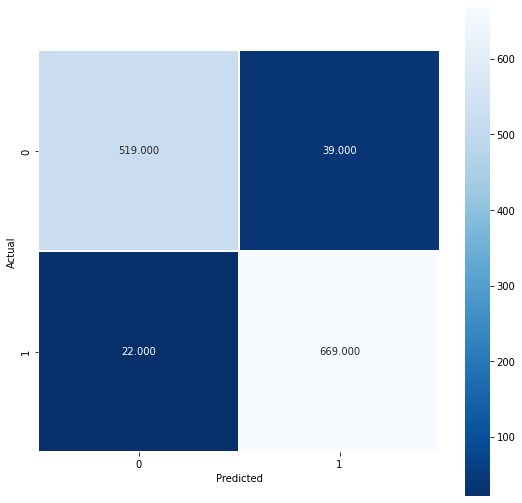

In [59]:
plt.figure(figsize=(9,9))
sns.heatmap(RFC2_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [61]:
print(roc_auc_score(Yr_test,RFC_yr_pred))

0.9491348054090223


# XGBOOST

In [63]:
XGB=XGBClassifier()
XGB.fit(Xr_train,Yr_train)

C:\Users\Rishi\anaconda3\envs\Altair\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[13:30:33] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [64]:
XGB_yr_pred=XGB.predict(Xr_test)
print("Accuracy of XGB classifier on test data:{:.2f}".format(XGB.score(Xr_test,Yr_test)))

Accuracy of XGB classifier on test data:0.96


In [65]:
print(classification_report(Yr_test,XGB_yr_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       558
           1       0.96      0.97      0.96       691

    accuracy                           0.96      1249
   macro avg       0.96      0.96      0.96      1249
weighted avg       0.96      0.96      0.96      1249



In [66]:
XGB2_cm=confusion_matrix(Yr_test,XGB_yr_pred)
print(XGB2_cm)

[[528  30]
 [ 19 672]]


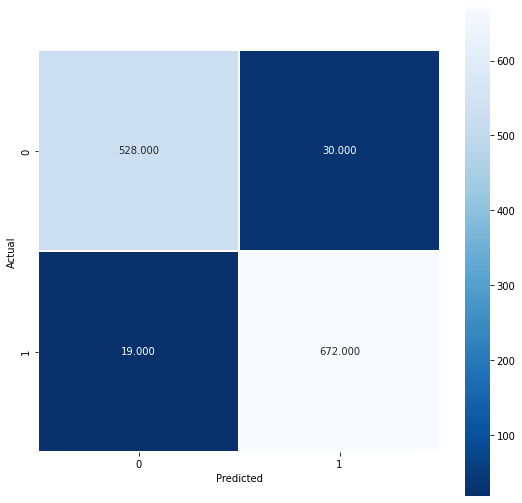

In [67]:
plt.figure(figsize=(9,9))
sns.heatmap(XGB2_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [68]:
print(roc_auc_score(Yr_test,XGB_yr_pred))

0.9593700885423961


# Naive Bayes

In [69]:
GNB=GaussianNB()
GNB.fit(Xr_train,Yr_train)

GaussianNB()

In [70]:
GNB_yr_pred=GNB.predict(Xr_test)
print("Accuracy of GNB classifier on test data:{:.2f}".format(GNB.score(Xr_test,Yr_test)))

Accuracy of GNB classifier on test data:0.91


In [71]:
print(classification_report(Yr_test,GNB_yr_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       558
           1       0.93      0.90      0.91       691

    accuracy                           0.91      1249
   macro avg       0.91      0.91      0.91      1249
weighted avg       0.91      0.91      0.91      1249



In [72]:
GNB2_cm=confusion_matrix(Yr_test,GNB_yr_pred)
print(GNB2_cm)

[[511  47]
 [ 69 622]]


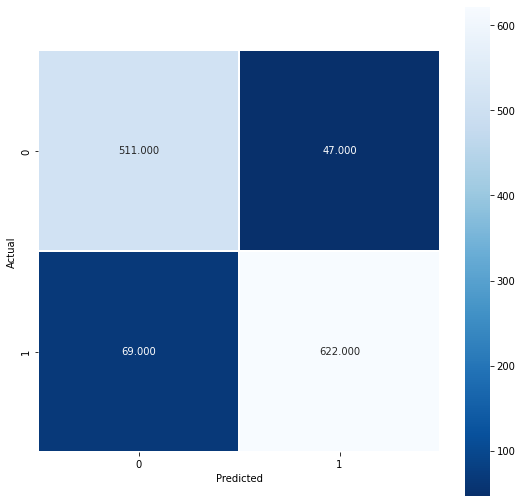

In [73]:
plt.figure(figsize=(9,9))
sns.heatmap(GNB2_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [74]:
print(roc_auc_score(Yr_test,GNB_yr_pred))

0.907957663559643


# LogisticRegression

In [75]:
logreg=LogisticRegression()
logreg.fit(Xr_train,Yr_train)

LogisticRegression()

In [76]:
logreg_yr_pred=logreg.predict(Xr_test)
print("Accuracy of logrec classifier on test data:{:.2f}".format(logreg.score(Xr_test,Yr_test)))

Accuracy of logrec classifier on test data:0.93


In [77]:
print(classification_report(Yr_test,logreg_yr_pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       558
           1       0.93      0.94      0.93       691

    accuracy                           0.93      1249
   macro avg       0.93      0.92      0.93      1249
weighted avg       0.93      0.93      0.93      1249



In [78]:
LR2_cm=confusion_matrix(Yr_test,logreg_yr_pred)

In [79]:
print(LR2_cm)

[[508  50]
 [ 42 649]]


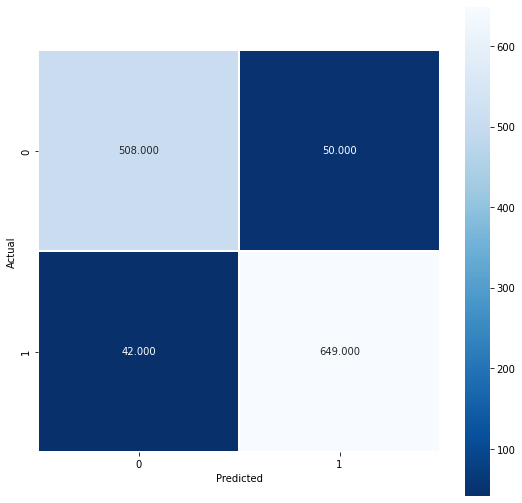

In [80]:
plt.figure(figsize=(9,9))
sns.heatmap(LR2_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [81]:
print(roc_auc_score(Yr_test,logreg_yr_pred))

0.924806394555706


# DEEP LEARNING MODEL

In [82]:
model.fit(Xr_train,Yr_train,epochs=100)

Train on 4958 samples
Epoch 1/100
4958/4958 [==============================] - 0s 87us/sample - loss: 0.2031 - accuracy: 0.9175
Epoch 2/100
4958/4958 [==============================] - 0s 62us/sample - loss: 0.1669 - accuracy: 0.9316
Epoch 3/100
4958/4958 [==============================] - 0s 62us/sample - loss: 0.1565 - accuracy: 0.9357
Epoch 4/100
4958/4958 [==============================] - 0s 62us/sample - loss: 0.1510 - accuracy: 0.9381
Epoch 5/100
4958/4958 [==============================] - 0s 61us/sample - loss: 0.1447 - accuracy: 0.9423
Epoch 6/100
4958/4958 [==============================] - 0s 63us/sample - loss: 0.1410 - accuracy: 0.9451
Epoch 7/100
4958/4958 [==============================] - 0s 60us/sample - loss: 0.1359 - accuracy: 0.9449
Epoch 8/100
4958/4958 [==============================] - 0s 61us/sample - loss: 0.1336 - accuracy: 0.9470
Epoch 9/100
4958/4958 [==============================] - 0s 62us/sample - loss: 0.1304 - accuracy: 0.9496
Epoch 10/100
4958/4958 [

In [83]:
model.evaluate(Xr_test,Yr_test)

1240/1240 [==============================] - 0s 70us/sample - loss: 0.1385 - accuracy: 0.9556


[0.13853475476104404, 0.95564514]

In [82]:
model_yr_pred=model.predict(Xr_test)
model_yr_pred_classes = model.predict_classes(Xr_test)

In [85]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(Yr_test, model_yr_pred_classes)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(Yr_test, model_yr_pred_classes)
print('Precision: %f' % precision)
# recall: tp / (tp + fn)
recall = recall_score(Yr_test, model_yr_pred_classes)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(Yr_test, model_yr_pred_classes)
print('F1 score: %f' % f1)

Accuracy: 0.955645
Precision: 0.962209
Recall: 0.958032
F1 score: 0.960116


In [86]:
model2_cm=confusion_matrix(Yr_test,model_yr_pred_classes)
print(model2_cm)

[[523  26]
 [ 29 662]]


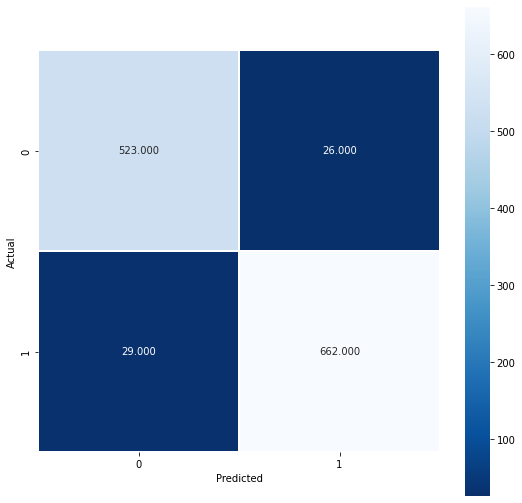

In [87]:
plt.figure(figsize=(9,9))
sns.heatmap(model2_cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual');
plt.xlabel('Predicted');

In [83]:
print(roc_auc_score(Yr_test,model_yr_pred))

0.7840618500018155


In [88]:
All_Models=["LogisticRegression","RandomForestClassifier","XGBClassifier","GaussianNB","Deep Learning Model"]
Accuracy=[92,97,97,89,95.5]
c = ['red', 'yellow', 'pink', 'blue', 'green']

Text(0.5, 1.0, 'PERFORMANCE OF ALL MODELS AFTER APPLYING SMOTEENN')

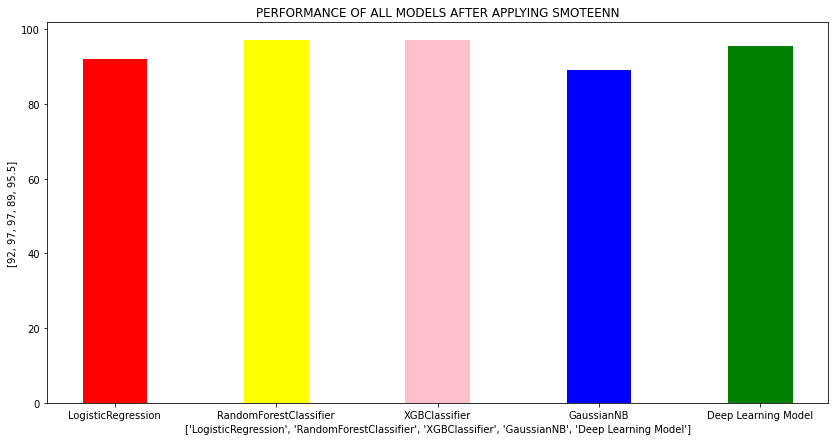

In [89]:
fig = plt.figure(figsize = (14, 7))
plt.bar(All_Models, Accuracy, color = c,width = 0.4)
plt.xlabel(All_Models)
plt.ylabel(Accuracy)
plt.title('PERFORMANCE OF ALL MODELS AFTER APPLYING SMOTEENN')